# OCR Output Review Tool
Interactive review of Gemini OCR results with manual correction capabilities.
- Identify low-confidence text blocks (< 0.9)
- View original images for verification
- Correct OCR errors
- Save corrected results

In [1]:
import json
import pandas as pd
# import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
# from IPython.display import Image as IPImage, display, HTML
# import os
import _02_02_clean_OCR_chars

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Setup project paths
script_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()
project_root = script_dir if (script_dir / "data").exists() else script_dir.parent

ocr_output_file = project_root / "data" / "02_raw_batch_mass" / "ocr_output_combined_sorted_batch_mass_2026.03.jsonl"
preprocessed_dir = project_root / "data" / "01_preprocessed"
preprocessed_meta_csv = preprocessed_dir / "all_metadata.csv"
review_output_file = project_root / "data" / "02_raw_batch_mass" / "ocr_output_reviewed_batch_mass_2026.03.jsonl"

print(f"Input file exists: {ocr_output_file.exists()}")

Input file exists: True


In [3]:
meta_df = pd.read_csv(preprocessed_meta_csv, encoding='utf-8')
print(f"Total metadata records loaded: {len(meta_df)}")
# meta_df['x_offset'] = pd.to(meta_df['x_offset'], errors='coerce')
# meta_df['y_offset'] = pd.to(meta_df['y_offset'], errors='coerce')
# print(type(meta_df['x_offset'][0]))
print(meta_df.head())

Total metadata records loaded: 3789
    pub_id        date  page_num  column  \
0  Alabama  0000-00-00         1       0   
1  Alabama  0000-00-00         1       1   
2  Alabama  0000-00-00         1       2   
3  Alabama  0000-00-00         2       0   
4  Alabama  0000-00-00         2       1   

                                                path  x_offset  y_offset  
0  data/01_preprocessed/Alabama/Alabama_p01_r00_c...         0      1533  
1  data/01_preprocessed/Alabama/Alabama_p01_r00_c...       867      1533  
2  data/01_preprocessed/Alabama/Alabama_p01_r00_c...      1547      1533  
3  data/01_preprocessed/Alabama/Alabama_p02_r00_c...         0       221  
4  data/01_preprocessed/Alabama/Alabama_p02_r00_c...       812       221  


In [4]:
# Load OCR output from JSONL, do initial autoclean
ocr_data = []
with open(ocr_output_file, 'r', encoding='utf-8') as f:
    for line in f:
        # print(line)
        if line.strip():
            ocr_data.append(json.loads(line))

df_ocr = pd.DataFrame(ocr_data)

df_ocr["text"] = df_ocr["text"].apply(_02_02_clean_OCR_chars.clean_text)
df_ocr["unexpected_chars"] = df_ocr["text"].apply(_02_02_clean_OCR_chars.has_unexpected_chars)

print(f"Total OCR records loaded: {len(df_ocr)}")
print(df_ocr.info())
print(f"\nFirst few rows:")
print(df_ocr.head())

Total OCR records loaded: 345088
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345088 entries, 0 to 345087
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   pub               345088 non-null  object 
 1   page              345088 non-null  int64  
 2   col               345088 non-null  int64  
 3   text              345088 non-null  object 
 4   conf              345088 non-null  float64
 5   x                 345088 non-null  int64  
 6   y                 345088 non-null  int64  
 7   width             345088 non-null  int64  
 8   height            345088 non-null  float64
 9   unexpected_chars  345088 non-null  bool   
dtypes: bool(1), float64(2), int64(5), object(2)
memory usage: 24.0+ MB
None

First few rows:
       pub  page  col                               text  conf    x    y  \
0  Alabama     1    0                            ALABAMA  0.99  534   21   
1  Alabama     1    0             

In [5]:
# Identify low-confidence items
# df_ocr['conf'] = pd.to(df_ocr['conf'], errors='coerce')

low_conf_threshold = 0.90
df_low_conf = df_ocr[(df_ocr['conf'] < low_conf_threshold) | df_ocr['unexpected_chars']]

print(f"Confidence Score Statistics:")
print(df_ocr['conf'].describe())
print(f"\n---")
print(f"Records with confidence < {low_conf_threshold} or unexpected characters: {len(df_low_conf)} out of {len(df_ocr)}")
print(f"Percentage: {100 * len(df_low_conf) / len(df_ocr):.4f}%")
print(f"\nConfidence distribution:")
print(df_ocr['conf'].value_counts().sort_index(ascending=True))


Confidence Score Statistics:
count    345088.000000
mean          0.986445
std           0.006612
min           0.850000
25%           0.980000
50%           0.990000
75%           0.990000
max           0.990000
Name: conf, dtype: float64

---
Records with confidence < 0.9 or unexpected characters: 191 out of 345088
Percentage: 0.0553%

Confidence distribution:
conf
0.85         7
0.88         1
0.90        28
0.92        90
0.93         1
0.94       116
0.95      2218
0.96      2802
0.97      9425
0.98     84975
0.99    245425
Name: count, dtype: int64


In [6]:
df_low_conf.head()

,pub,page,col,text,conf,x,y,width,height,unexpected_chars
2676,Alabama,11,0,"JONES, ELI SPEAR-Ala.2,'83; (l 83) · 730",0.99,226,278,744,24.0,True
7689,Arkansas,5,1,"GILLIAM, JAMES C. (b'65)⊕┇; (l 03)",0.99,41,122,505,18.0,True
8820,Arkansas,9,1,"Holt, A. H. (b'61)-│ (l 03); 710 South",0.92,56,535,594,23.0,True
11383,Arkansas,18,2,†); OALR★; ▼,0.99,80,551,175,16.0,True
11401,Arkansas,18,2,"(l 07); (Texarkana, Tex. †); S",0.99,80,785,363,16.0,True


In [7]:
# Helper function to find original image file
def find_original_image(state, page_num, col_idx):
    """
    Reconstruct the original image path from preprocessed directory.
    Images are stored as: data/01_preprocessed/{state}/{state}_p{page}_r00_c{col}.jpg
    """
    
    # Construct expected filename pattern
    img_path = preprocessed_dir / state /  f"{state}_p{page_num:02d}_r00_c{col_idx:03d}.jpg"
    if img_path.exists():
        return img_path
    
    return None

# Test the function
test_result = find_original_image(df_low_conf.iloc[0]['pub'] if len(df_low_conf) > 0 else 'Texas', 1, 0)
print(f"Test image search result: {test_result}")
print(f"Test path exists: {test_result.exists() if test_result else False}")

Test image search result: d:\Google Drive (smith318)\newspaper_ocr\newspaper_utilities\data\01_preprocessed\Alabama\Alabama_p01_r00_c000.jpg
Test path exists: True



Item 5 of 191
Publication: Arkansas, Page: 18, Column: 2
Confidence: 0.9900
Has unexpected characters: True
Original Index: 11401
OCR Text: (l 07); (Texarkana, Tex. †); S

Context:
            pub  page  col                                    text  conf   x  \
11398  Arkansas    18    2                  LANIER, LUCIAN HERBERT  0.99  63   
11399  Arkansas    18    2                   (See Texarkana, Tex.)  0.99  80   
11400  Arkansas    18    2     LEE, AUGUSTUS G. (b'76)⊕-Mo.28,'01;  0.99  63   
11401  Arkansas    18    2          (l 07); (Texarkana, Tex. †); S  0.99  80   
11402  Arkansas    18    2  LENNARD, F. M. (b'50)-Ky.1,'84; (l 03)  0.99  63   
11403  Arkansas    18    2     LIGHTFOOT, JEAN A. (b'62)-La.1,'92;  0.99  63   
11404  Arkansas    18    2             (l t); (Texarkana, Tex.; †)  0.99  80   
11405  Arkansas    18    2       MANN, ROBT. HOWELL TAYLOR (b'68)⊕  0.99  63   

         y  width  height  unexpected_chars  
11398  746    361    16.0             False  
11399

<Figure size 1000x1200 with 0 Axes>

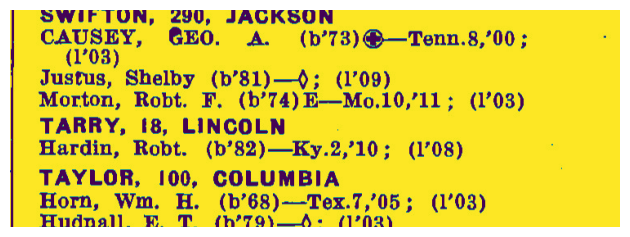

In [8]:
def display_review_item(index):
    """Display a single low-confidence item with image and text fields for correction"""
    if index >= len(df_low_conf):
        print("✓ All items reviewed!")
        return
    
    row = df_low_conf.iloc[index]
    orig_index = df_low_conf.index[index]
    
    # Find original image
    img_path = find_original_image(row['pub'], row['page'], row['col'])
    
    print(f"\n{'='*80}")
    print(f"Item {index + 1} of {len(df_low_conf)}")
    print(f"{'='*80}")
    print(f"Publication: {row['pub']}, Page: {row['page']}, Column: {row['col']}")
    print(f"Confidence: {row['conf']:.4f}")
    print(f"Has unexpected characters: {row['unexpected_chars']}")
    print(f"Original Index: {orig_index}")
    print(f"OCR Text: {row['text']}")
       
    print(f"\nContext:")
    print(df_ocr.loc[orig_index - 3: orig_index + 4])
    # Display bounding box info
    print(f"Bounding Box: x={row['x']}, y={row['y']}, w={row['width']}, h={row['height']}")
    meta_row = meta_df.loc[
        (meta_df["pub_id"] == row['pub']) & 
        (meta_df["page_num"] == row['page']) & 
        (meta_df["column"] == row['col'])
    ][["x_offset", "y_offset"]]
    x = row['x'] - float(meta_row['x_offset'].iloc[0]) # offset x for the column images
    y = row['y'] - float(meta_row['y_offset'].iloc[0])
    

    print(f"Bounding Box: x={x}, y={y}, w={row['width']}, h={row['height']}")
    
    # Display image if found
    if img_path:
        print(f'\n📷 Original Image: "{img_path}"')
        img = Image.open(img_path)
        plt.figure(figsize=(10, 12))
        fig, ax = plt.subplots()
        ax.imshow(img)
        plt.axis('off')
        rect = plt.Rectangle(
            (x, y),
            row['width'],
            row['height'],
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)
        #ax.set_title(f"Original Column Image - {row['pub']} p{row['page']} c{row['col']}")
        ax.set_ylim(y + 100, y - row["height"] - 150)
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️  Original image not found at expected location")
 

# Display first low-confidence item
display_review_item(4)

In [9]:
# functions for interactions
def update_display(change=None):
    """Update display when item index changes"""
    idx = current_idx.value
    row = df_low_conf.iloc[idx]
    
    corrected_text.value = row['text']
    confidence_display.value = f"<b>Confidence: {row['conf']:.4f}</b> | Pub: {row['pub']} | Page: {row['page']} | Col: {row['col']}"
    status_display.value = f"<i>Item {idx + 1} of {len(df_low_conf)} | Reviewed: {review_state['reviewed_count']}</i>"

    context_display.value = f"""
    <b>Context:</b><br>
    {df_ocr.loc[df_low_conf.index[idx] - 2: df_low_conf.index[idx] - 1].to_html()}
    <b>{df_ocr.loc[[df_low_conf.index[idx]]].to_html()}</b>
    {df_ocr.loc[df_low_conf.index[idx] + 1: df_low_conf.index[idx] + 2].to_html()}
    """
    
    # Display image
    img_path = find_original_image(row['pub'], row['page'], row['col'])
    if img_path:
        with open(img_path, "rb") as file:
            image_bytes = file.read()
        image_widget.value = image_bytes
def on_save_correction(b):
    idx = current_idx.value
    orig_idx = df_low_conf.index[idx]
    review_state['corrections'][orig_idx] = corrected_text.value.strip()
    review_state['reviewed_count'] += 1
    if idx < len(df_low_conf) - 1:
        current_idx.value = idx + 1
    
def on_skip(b):
    idx = current_idx.value
    review_state['skipped'].add(idx)
    if idx < len(df_low_conf) - 1:
        current_idx.value = idx + 1

def on_previous(b):
    if current_idx.value > 0:
        current_idx.value = current_idx.value - 1

In [10]:
if len(df_low_conf) <= 0:
    print("No low confidence OCR recorded!")
else:
    # Create review state tracking dictionary
    review_state = {
        'current_index': 0,
        'corrections': {},  # Store {original_index: corrected_text}
        'skipped': set(),
        'reviewed_count': 0
    }

    # Create interactive review interface
    current_idx = widgets.IntSlider(value=0, min=0, max=len(df_low_conf)-1, step=1, description='Item:', width='600px')
    corrected_text = widgets.Text(value='', placeholder='Enter corrected text', description='Correction:', width='900px')
    confidence_display = widgets.HTML(value='')
    status_display = widgets.HTML(value='')
    context_display = widgets.HTML(value='')
    character_bank = widgets.HTML(value='▼ ⊕ ◊ ★ † ♁ ‡ △')

    row = df_low_conf.iloc[0]
    img_path = find_original_image(row['pub'], row['page'], row['col'])
    if img_path:
        with open(img_path, "rb") as file:
            image_bytes = file.read()
        image_widget = widgets.Image(
            value=image_bytes,
            format='jpg',
            width=300,
            height=900,
            layout=widgets.Layout(object_fit='scale-down') # Optional styling
        )

    current_idx.observe(update_display, names='value')

    # Buttons for navigation and saving
    btn_save_correction = widgets.Button(description='Save & Next', button_style='success')
    btn_skip = widgets.Button(description='Skip', button_style='info')
    btn_previous = widgets.Button(description='Previous', button_style='warning')

    btn_save_correction.on_click(on_save_correction)
    btn_skip.on_click(on_skip)
    btn_previous.on_click(on_previous)
    buttons_box = widgets.HBox([btn_previous, btn_skip, btn_save_correction])

    control_box = widgets.VBox([
        confidence_display,
        status_display,
        current_idx,
        corrected_text,
        character_bank,
        buttons_box,
        context_display
    ])

    # Display the interface
    update_display()
    display(widgets.HBox([control_box, image_widget]))

In [11]:
# Summary of corrections
print("="*80)
print("REVIEW SUMMARY")
print("="*80)
print(f"Total low-confidence items: {len(df_low_conf)}")
print(f"Items reviewed & corrected: {len(review_state['corrections'])}")
print(f"Items skipped: {len(review_state['skipped'])}")
print(f"Items not yet reviewed: {len(df_low_conf) - len(review_state['corrections']) - len(review_state['skipped'])}")
# print("\nSample corrections made:")
# for orig_idx, corrected_text in list(review_state['corrections'].items())[:5]:
#     print(f"  Index {orig_idx}: {corrected_text[:60]}")

REVIEW SUMMARY
Total low-confidence items: 191
Items reviewed & corrected: 190
Items skipped: 1
Items not yet reviewed: 0


In [12]:
# Apply corrections to original data and save to new file
df_reviewed = df_ocr.copy()

# Apply corrections
for orig_idx, corrected_text in review_state['corrections'].items():
    df_reviewed.loc[orig_idx, 'text'] = corrected_text
    df_reviewed.loc[orig_idx, 'conf'] = 1.0  # Set confidence to 1.0 for corrected items

# Mark items as reviewed
#df_reviewed['reviewed'] = df_reviewed.index.isin(review_state['corrections'].keys())

print(f"Total records to save: {len(df_reviewed)}")
print(f"Records with corrections: {df_reviewed['conf'].eq(1.0).sum()}")
print(f"\nSample of reviewed data:")
print(df_reviewed[df_reviewed['conf'] == 1.0].head())

df_reviewed["unexpected_chars"]= df_reviewed["text"].apply(_02_02_clean_OCR_chars.has_unexpected_chars)
unexpected_df = df_reviewed[df_reviewed['unexpected_chars']]
if len(unexpected_df) > 0:
    print(f"*** Remaining text with unexpected characters n=({len(unexpected_df)})!! ***")
else:
    print("No remaining unexpected characters")

Total records to save: 345088
Records with corrections: 190

Sample of reviewed data:
            pub  page  col                                      text  conf  \
2676    Alabama    11    0  JONES, ELI SPEAR-Ala.2,'83; (l 83) ; 730   1.0   
7689   Arkansas     5    1       GILLIAM, JAMES C. (b'65)⊕-◊; (l 03)   1.0   
8820   Arkansas     9    1   Holt, A. H. (b'61)-◊; (l 03); 710 South   1.0   
11383  Arkansas    18    2                             (♁); OALR★; ▼   1.0   
11401  Arkansas    18    2            (l 07); (Texarkana, Tex. ♁); S   1.0   

         x    y  width  height  unexpected_chars  
2676   226  278    744    24.0              True  
7689    41  122    505    18.0              True  
8820    56  535    594    23.0              True  
11383   80  551    175    16.0              True  
11401   80  785    363    16.0              True  
*** Remaining text with unexpected characters n=(12)!! ***


In [ ]:
unexpected_df

,pub,page,col,text,conf,x,y,width,height,unexpected_chars
58848,Illinois,30,0,"Ireland, Jay (b'89)-Ill.1,'17; (l 17); ▄",1.00,238,1452,741,23.0,True
82611,Indiana,17,0,"R.D. ""G""; office, Asylum for the Insane",1.00,224,1199,746,24.0,True
83164,Indiana,19,0,"R.D. ""G""",1.00,231,524,164,21.0,True
83660,Indiana,20,2,"(l 97); R.D. ""D""",1.00,66,633,174,16.0,True
126646,Massachusetts,12,1,"L'ESPERANCE, OSCAR RAÖUL TALON",1.00,54,1088,444,16.0,True
176096,Nebraska,1,1,"COX, JOHN L. (b'78)⊕-Mo.22,'03; ╰);",1.00,53,161,489,19.0,True
184621,New Jersey,8,1,"HÜGER, JOS. (b'57)-N.Y.1,'80; (l 80)",1.00,48,1263,398,18.0,True
209603,New York,65,0,"Debon, Amédée Jos. (b'83)-N.Y.1,'11;",1.00,243,1113,488,16.0,True
219910,New York,100,0,"STADTMÜLLER, NORBERT (b'65)-Ger.16,",1.00,181,919,414,16.0,True
258120,Oklahoma,11,2,"MOYERS, -, PUSHMAТAHA",1.00,46,749,268,15.0,True


In [13]:
# Save reviewed results to new JSONL file
def save_reviewed_output(df, output_path):
    """Save dataframe to JSONL format"""
    with open(output_path, 'w', encoding='utf-8') as f:
        for idx, row in df.iterrows():
            # Reconstruct the original entry format
            entry = {
                'pub': row['pub'],
                'page': row['page'],
                'col': row['col'],
                'text': row['text'],
                'conf': row['conf'] if isinstance(row['conf'], (int, float)) else float(row['conf']),
                'x': row['x'],
                'y': row['y'],
                'width': row['width'],
                'height': row['height'],
            }
            f.write(json.dumps(entry, ensure_ascii=False) + '\n')
    return output_path

# Save the reviewed data
output_path = save_reviewed_output(df_reviewed, review_output_file)
print(f"✓ Reviewed data saved to: {output_path}")
print(f"✓ Total records: {len(df_reviewed)}")
print(f"✓ Corrected records: {df_reviewed['conf'].eq(1.0).sum()}")

# Verify the output file
with open(output_path, 'r', encoding='utf-8') as f:
    sample_lines = [json.loads(line) for line in list(f)[:2]]
    
print(f"\n✓ Verification - First 2 records from new file:")
for i, entry in enumerate(sample_lines):
    print(f"\nRecord {i+1}:")
    print(f"  Text: {entry['text'][:60]}...")
    print(f"  Confidence: {entry['conf']}")
    print(f"  Reviewed: {entry.get('reviewed', False)}")

✓ Reviewed data saved to: d:\Google Drive (smith318)\newspaper_ocr\newspaper_utilities\data\02_raw_batch_mass\ocr_output_reviewed_batch_mass_2026.03.jsonl
✓ Total records: 345088
✓ Corrected records: 190

✓ Verification - First 2 records from new file:

Record 1:
  Text: ALABAMA...
  Confidence: 0.99
  Reviewed: False

Record 2:
  Text: ABANDA, 125, CHAMBERS...
  Confidence: 0.99
  Reviewed: False


In [15]:
# Final statistics and comparison
print("\n" + "="*80)
print("FINAL STATISTICS")
print("="*80)

# Load both files for comparison
df_original = pd.read_json(ocr_output_file, lines=True, encoding='utf-8')
df_final = pd.read_json(review_output_file, lines=True, encoding='utf-8')

print(f"\nOriginal OCR Output:")
print(f"  Total records: {len(df_original)}")
print(f"  Low confidence (<0.90): {(df_original['conf'] < 0.90).sum()}")
print(f"  Have unexpected characters: {df_original["text"].apply(_02_02_clean_OCR_chars.has_unexpected_chars).sum()}")
print(f"  Average confidence: {df_original['conf'].mean():.4f}")

print(f"\nReviewed Output:")
print(f"  Total records: {len(df_final)}")
#print(f"  Reviewed records: {df_final['reviewed'].sum() if 'reviewed' in df_final.columns else 'N/A'}")
print(f"  Low confidence (<0.90): {(df_final['conf'] < 0.90).sum()}")
print(f"  Have unexpected characters: {df_final["text"].apply(_02_02_clean_OCR_chars.has_unexpected_chars).sum()}")
print(f"  Average confidence: {df_final['conf'].mean():.4f}")

print(f"\nOutput saved to: {review_output_file}")
print(f"Ready for next processing step!")


FINAL STATISTICS

Original OCR Output:
  Total records: 345088
  Low confidence (<0.90): 8
  Have unexpected characters: 64436
  Average confidence: 0.9864

Reviewed Output:
  Total records: 345088
  Low confidence (<0.90): 0
  Have unexpected characters: 12
  Average confidence: 0.9865

Output saved to: d:\Google Drive (smith318)\newspaper_ocr\newspaper_utilities\data\02_raw_batch_mass\ocr_output_reviewed_batch_mass_2026.03.jsonl
Ready for next processing step!
